<a href="https://colab.research.google.com/github/hanif562/project-PUI/blob/main/Hybrid_CNN_YOLO_Deteksi_Telur_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# cek GPU
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
# mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# install library YOLO
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.9 MB/s eta 0:00:00


In [23]:
# import library
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import shutil

from ultralytics import YOLO
from tensorflow.keras.models import load_model
from google.colab import files

print("Library siap digunakan")

Library siap digunakan


In [5]:
# cek file model di Google Drive
import os

folder = "/content/drive/MyDrive/PUI_DATASET_FINAL"

for root, dirs, files in os.walk(folder):
    for file in files:
        if file.endswith(".pt") or file.endswith(".h5") or file.endswith(".keras"):
            print(os.path.join(root, file))

/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_training_cnn/egg_cnn_mobilenetv2_final.keras
/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_training_cnn/best_egg_cnn_mobilenetv2.keras
/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_training_telur_v2_70_30/egg_cnn_mobilenetv2_final.keras
/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_training_telur_v2_70_30/best_egg_cnn_mobilenetv2_70_30.keras
/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_yolo_deteksi_telur_v8/weights/best.pt
/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_yolo_deteksi_telur_v8/weights/last.pt


In [22]:
# load mmodel
from ultralytics import YOLO
from tensorflow.keras.models import load_model

yolo_path = "/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_yolo_deteksi_telur_v8/weights/best.pt"
cnn_path  = "/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_training_telur_v2_70_30/best_egg_cnn_mobilenetv2_70_30.keras"

yolo_model = YOLO(yolo_path)
cnn_model = load_model(cnn_path)

class_names = ["Baik", "Cukup", "Rusak"]

print("Model YOLO berhasil dimuat")
print("Model CNN berhasil dimuat")

Model YOLO berhasil dimuat
Model CNN berhasil dimuat


In [10]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from tensorflow.keras.models import load_model

In [11]:
# Load model
yolo_path = "/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_yolo_deteksi_telur_v8/weights/best.pt"
cnn_path  = "/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_training_telur_v2_70_30/best_egg_cnn_mobilenetv2_70_30.keras"

yolo_model = YOLO(yolo_path)
cnn_model = load_model(cnn_path)

class_names = ["baik", "cukup", "rusak"]

print("Model YOLO dan CNN berhasil dimuat")

Model YOLO dan CNN berhasil dimuat


In [36]:
uploaded = files.upload()

Saving rusak_177.jpg to rusak_177.jpg



image 1/1 /content/rusak_177.jpg: 512x416 1 retak, 1 telur, 78.6ms
Speed: 1.4ms preprocess, 78.6ms inference, 0.8ms postprocess per image at shape (1, 3, 512, 416)

===== HASIL AKHIR HYBRID =====
File gambar        : rusak_177.jpg
Ada retak dari YOLO: True
Klasifikasi CNN    : Rusak
Confidence CNN     : 0.991902768611908
Keputusan akhir    : Rusak


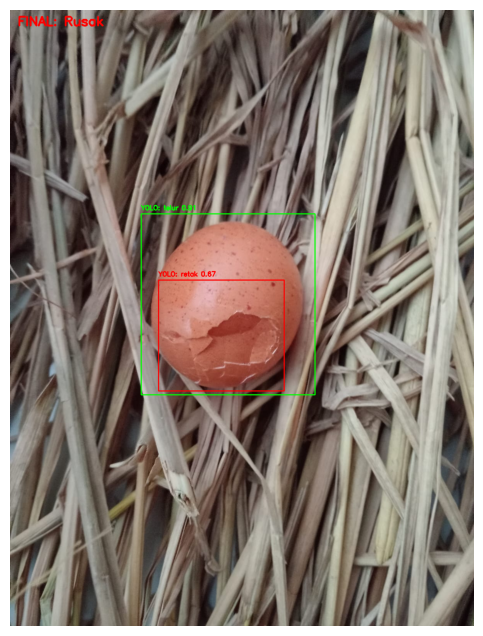

In [45]:
for filename in uploaded.keys():

    img = cv2.imread(filename)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ada_retak = False
    hasil_cnn_telur = None
    conf_cnn_telur = None

    results = yolo_model.predict(
        source=filename,
        conf=0.25,
        save=False
    )

    h, w, _ = img_rgb.shape

    for r in results:
        for box in r.boxes:

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            yolo_conf = float(box.conf[0])
            yolo_cls = int(box.cls[0])
            yolo_label = yolo_model.names[yolo_cls].lower()

            if yolo_label == "retak":
                ada_retak = True

            if yolo_label == "telur":


                # CROP TELUR
                pad = 0.40

                bw = x2 - x1
                bh = y2 - y1

                x1_pad = max(0, int(x1 - bw * pad))
                y1_pad = max(0, int(y1 - bh * pad))
                x2_pad = min(w, int(x2 + bw * pad))
                y2_pad = min(h, int(y2 + bh * pad))

                crop = img_rgb[y1_pad:y2_pad, x1_pad:x2_pad]

                if crop.size == 0:
                    continue

                crop_resize = cv2.resize(crop, (224, 224))

                # PENTING:
                # Jangan dibagi 255 karena model CNN kamu sudah punya preprocess_input
                crop_input = np.expand_dims(crop_resize, axis=0)

                pred = cnn_model.predict(crop_input, verbose=0)
                cnn_idx = np.argmax(pred)

                hasil_cnn_telur = class_names[cnn_idx]
                conf_cnn_telur = float(np.max(pred))


            # GAMBAR BOX YOLO
            color = (255, 0, 0) if yolo_label == "retak" else (0, 255, 0)

            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)

            cv2.putText(
                img_rgb,
                f"YOLO: {yolo_label} {yolo_conf:.2f}",
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                color,
                2
            )


    # KEPUTUSAN FINAL
    if ada_retak:
        keputusan_akhir = "Rusak"
    else:
        keputusan_akhir = hasil_cnn_telur

    print("\n===== HASIL AKHIR HYBRID =====")
    print("File gambar        :", filename)
    print("Ada retak dari YOLO:", ada_retak)
    print("Klasifikasi CNN    :", hasil_cnn_telur)
    print("Confidence CNN     :", conf_cnn_telur)
    print("Keputusan akhir    :", keputusan_akhir)

    final_color = (255, 0, 0) if keputusan_akhir == "Rusak" else (0, 255, 0)

    cv2.putText(
        img_rgb,
        f"FINAL: {keputusan_akhir}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.1,
        final_color,
        3
    )

    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

In [46]:
import json
import os

save_drive = "/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_hybrid_yolo_cnn"

class_indices = {
    "0": "Baik",
    "1": "Cukup",
    "2": "Rusak"
}

with open(os.path.join(save_drive, "class_indices.json"), "w") as f:
    json.dump(class_indices, f)

print("class_indices.json berhasil disimpan")

class_indices.json berhasil disimpan


In [47]:
# simpan hasil training hybrid ke Google Drive
import os
import shutil

save_drive = "/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_hybrid_yolo_cnn"
os.makedirs(save_drive, exist_ok=True)

# simpan model CNN hybrid
cnn_model.save(os.path.join(save_drive, "cnn_model_hybrid.keras"))

# simpan model YOLO yang dipakai
shutil.copy(
    "/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_yolo_deteksi_telur_v8/weights/best.pt",
    os.path.join(save_drive, "yolo_best.pt")
)

print("Hasil training hybrid berhasil disimpan ke Drive:")
print(save_drive)

Hasil training hybrid berhasil disimpan ke Drive:
/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_hybrid_yolo_cnn
